# Pairwise Condition Comparisons (t-tests)

Two-sided **Welch t-tests for every pair of conditions** (10 pairs across the 5 conditions) on
the study's key outcomes, complementing `deep_analysis_notebook.ipynb`, which tests each
intervention only against the `ai` baseline (directionally, per the preregistrations).

**Conventions**

* All tests here are **exploratory and two-sided** — pairs of interventions have no
  preregistered direction.
* Welch's t (no equal-variance assumption) with **Hedges' g** and 95% CI; sign convention:
  g > 0 means the **first-listed** condition of the pair is higher.
* **Holm correction within each outcome** (10 comparisons per outcome). With 15 outcomes ×
  10 pairs = 150 tests, uncorrected p-values must not be read as findings.
* A **Mann–Whitney U** test accompanies every pair as a distribution-free robustness check
  (relevant for skewed outcomes such as prompts per task and completion time).
* Pairs that cross the two collection waves (`ai` and `ai-reliability` were collected in
  July 2026; `alternatives`, `pause-points`, `reflection-task` in August 2026) are flagged
  `cross_wave` — those comparisons carry the cohort confound documented in the main notebook
  (modules B and O).

**Requires:** `notebook_analysis_output/participant_metrics.csv`, produced by running
`deep_analysis_notebook.ipynb` (Part 1 + module Q) first.

### 1. Setup and data

In [1]:
from __future__ import annotations

import math
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm

CONDITIONS = ["ai", "ai-reliability", "alternatives", "pause-points", "reflection-task"]
CONDITION_LABELS = {
    "ai": "AI (baseline)", "ai-reliability": "Reliability cards", "alternatives": "Alternatives",
    "pause-points": "Pause points", "reflection-task": "Reflection task",
}
SHORT_LABELS = {"ai": "AI", "ai-reliability": "Rel. cards", "alternatives": "Alternatives",
                "pause-points": "Pause pts", "reflection-task": "Reflection"}
WAVE_OF = {"ai": 1, "ai-reliability": 1, "alternatives": 2, "pause-points": 2,
           "reflection-task": 2}  # ai includes 5 wave-2 participants (~3%); treated as wave 1
ALPHA = 0.05
Z_CRIT = norm.ppf(0.975)

METRICS_CSV = Path("notebook_analysis_output/participant_metrics.csv")
if not METRICS_CSV.exists():
    raise FileNotFoundError(
        f"{METRICS_CSV} not found - run deep_analysis_notebook.ipynb (Part 1 and module Q) "
        "first; it exports the participant-level metrics this notebook tests.")

participants = pd.read_csv(METRICS_CSV, dtype={"participant_id": str})
eligible = participants[~participants["exclude_primary"]].copy()
eligible["condition"] = pd.Categorical(eligible["condition"], categories=CONDITIONS, ordered=True)
print(f"analysis sample: {len(eligible)} of {len(participants)} participants "
      f"(exclusions from the main notebook applied)")

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c8c8c4", "axes.labelcolor": "#33322e", "axes.titlecolor": "#33322e",
    "xtick.color": "#6f6d66", "ytick.color": "#6f6d66", "text.color": "#33322e",
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
})

analysis sample: 917 of 925 participants (exclusions from the main notebook applied)


### 2. Outcomes tested

The four confirmatory outcome families, the calibration and confidence measures behind them,
the five standardized scales, and three behavioral/self-report measures.

In [2]:
OUTCOMES = [
    # column, label, family
    ("actual_score", "Actual score (0–12)", "primary"),
    ("absolute_estimation_error", "Metacognitive accuracy |est − actual|", "primary"),
    ("confidence_discrimination", "Confidence discrimination (pp)", "primary"),
    ("prompts_per_task", "Prompts per completed task", "primary"),
    ("mean_confidence", "Mean item confidence (0–100)", "confidence"),
    ("signed_estimation_error", "Signed estimation error (items)", "confidence"),
    ("signed_confidence_gap", "Signed confidence gap (pp)", "confidence"),
    ("sus_score", "SUS (0–100)", "scales"),
    ("ueq_overall", "UEQ-S overall (−3…+3)", "scales"),
    ("tlx_mean", "NASA-TLX (0–20)", "scales"),
    ("nfc_mean", "NFC (1–5)", "scales"),
    ("trust_mean", "Trust (1–5)", "scales"),
    ("completion_minutes", "Completion time (min)", "behavior"),
    ("mean_prompt_words", "Words per prompt", "behavior"),
    ("double_checked_answers", "“I double-checked AI answers” (1–5)", "behavior"),
]
OUTCOME_LABELS = {column: label for column, label, _ in OUTCOMES}

descriptives = (eligible.groupby("condition", observed=True)[[c for c, _, _ in OUTCOMES]]
                .agg(["mean", "std"]).round(2))
display(descriptives.T)

condition                           ai  ai-reliability  alternatives  \
actual_score              mean    5.57            5.18          5.20   
                          std     1.81            1.63          1.53   
absolute_estimation_error mean    4.42            3.35          2.96   
                          std     2.42            2.23          2.01   
confidence_discrimination mean    2.34            7.74          5.59   
                          std     8.92           12.53         13.59   
prompts_per_task          mean    1.59            1.61          1.77   
                          std     0.71            0.70          0.79   
mean_confidence           mean   79.06           68.94         69.78   
                          std    15.61           17.64         17.06   
signed_estimation_error   mean    4.12            3.04          2.50   
                          std     2.91            2.64          2.56   
signed_confidence_gap     mean   32.62           25.76         26.45   
                          std    22.06           22.68         20.30   
sus_score                 mean   79.51           74.56         67.46   
                          std    18.11           18.13         18.74   
ueq_overall               mean    1.31            1.07          0.80   
                          std     1.11            1.08          1.00   
tlx_mean                  mean    7.67            9.22          9.52   
                          std     3.28            2.89          2.86   
nfc_mean                  mean    3.53            3.42          3.43   
                          std     0.88            0.96          0.90   
trust_mean                mean    3.78            3.45          3.15   
                          std     0.76            0.77          0.81   
completion_minutes        mean   33.97           37.20         39.01   
                          std    14.92           16.34         15.92   
mean_prompt_words         mean  133.33          122.22        127.20   
                          std    80.04           74.82         65.79   
double_checked_answers    mean    3.39            3.55          3.73   
                          std     1.23            1.27          1.05   

condition                       pause-points  reflection-task  
actual_score              mean          4.49             5.52  
                          std           2.00             1.65  
absolute_estimation_error mean          3.61             4.03  
                          std           2.45             2.48  
confidence_discrimination mean          3.14             2.10  
                          std          11.78             9.35  
prompts_per_task          mean          3.68             2.28  
                          std           2.06             1.12  
mean_confidence           mean         66.84            76.97  
                          std          19.95            17.52  
signed_estimation_error   mean          3.28             3.63  
                          std           2.88             3.04  
signed_confidence_gap     mean         29.43            30.93  
                          std          23.78            22.25  
sus_score                 mean         59.86            72.77  
                          std          22.38            17.78  
ueq_overall               mean          0.21             0.86  
                          std           1.28             1.17  
tlx_mean                  mean          9.67            11.68  
                          std           2.85             3.36  
nfc_mean                  mean          3.46             3.37  
                          std           0.93             0.92  
trust_mean                mean          3.26             3.64  
                          std           0.81             0.78  
completion_minutes        mean         43.27            72.81  
                          std          15.54            27.28  
mean_prompt_words         mean         

### 3. All pairwise Welch t-tests

In [3]:
def hedges_g(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    nx, ny = len(x), len(y)
    pooled = ((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2)
    if pooled <= 0:
        return math.nan, math.nan, math.nan
    g = (x.mean() - y.mean()) / math.sqrt(pooled) * (1 - 3 / (4 * (nx + ny) - 9))
    se = math.sqrt((nx + ny) / (nx * ny) + g * g / (2 * (nx + ny - 2)))
    return g, g - Z_CRIT * se, g + Z_CRIT * se


def holm(pvalues: pd.Series) -> pd.Series:
    adjusted = pd.Series(np.nan, index=pvalues.index, dtype=float)
    valid = pvalues.dropna()
    running = 0.0
    for rank, (idx, p) in enumerate(valid.sort_values().items()):
        running = max(running, min(1.0, (len(valid) - rank) * p))
        adjusted[idx] = running
    return adjusted


def fmt_p(p: float) -> str:
    if not math.isfinite(p):
        return "–"
    return "< .001" if p < 0.001 else f"= {p:.3f}".replace("0.", ".")


PAIRS = list(combinations(CONDITIONS, 2))
rows = []
for column, label, family in OUTCOMES:
    for cond_a, cond_b in PAIRS:
        x = eligible.loc[eligible["condition"] == cond_a, column].dropna().to_numpy(float)
        y = eligible.loc[eligible["condition"] == cond_b, column].dropna().to_numpy(float)
        welch = stats.ttest_ind(x, y, equal_var=False)
        mwu = stats.mannwhitneyu(x, y, alternative="two-sided")
        g, g_low, g_high = hedges_g(x, y)
        rows.append({
            "outcome": column, "family": family,
            "pair": f"{SHORT_LABELS[cond_a]} vs {SHORT_LABELS[cond_b]}",
            "cond_a": cond_a, "cond_b": cond_b,
            "cross_wave": WAVE_OF[cond_a] != WAVE_OF[cond_b],
            "n_a": len(x), "n_b": len(y),
            "mean_a": x.mean(), "mean_b": y.mean(), "diff": x.mean() - y.mean(),
            "t": welch.statistic, "df": float(welch.df), "p": welch.pvalue,
            "hedges_g": g, "g_ci_low": g_low, "g_ci_high": g_high,
            "p_mwu": mwu.pvalue,
        })
pairwise = pd.DataFrame(rows)
pairwise["p_holm"] = pairwise.groupby("outcome")["p"].transform(holm)
pairwise["p_mwu_holm"] = pairwise.groupby("outcome")["p_mwu"].transform(holm)
pairwise["significant"] = pairwise["p_holm"] < ALPHA
print(f"{len(pairwise)} tests: {len(OUTCOMES)} outcomes × {len(PAIRS)} pairs "
      f"(Holm-corrected within outcome); {int(pairwise['significant'].sum())} significant")

150 tests: 15 outcomes × 10 pairs (Holm-corrected within outcome); 80 significant


### 4. Full results — primary outcomes

(The complete table for all 15 outcomes is exported in Section 8; the summary in Section 6
lists every Holm-significant pair.)

In [4]:
def show_outcome(column: str) -> None:
    block = pairwise[pairwise["outcome"] == column].copy()
    block["g [95% CI]"] = block.apply(
        lambda r: f"{r.hedges_g:+.2f} [{r.g_ci_low:+.2f}, {r.g_ci_high:+.2f}]", axis=1)
    block["wave"] = np.where(block["cross_wave"], "cross", "same")
    view = block[["pair", "wave", "mean_a", "mean_b", "diff", "t", "df",
                  "p", "p_holm", "p_mwu_holm", "g [95% CI]", "significant"]].copy()
    view[["mean_a", "mean_b", "diff", "t"]] = view[["mean_a", "mean_b", "diff", "t"]].round(2)
    view["df"] = view["df"].round(1)
    for pcol in ("p", "p_holm", "p_mwu_holm"):
        view[pcol] = view[pcol].map(fmt_p)
    print(f"\n{OUTCOME_LABELS[column]}")
    display(view.style.hide(axis="index"))


for column, _, family in OUTCOMES:
    if family == "primary":
        show_outcome(column)


Actual score (0–12)


pair,wave,mean_a,mean_b,diff,t,df,p,p_holm,p_mwu_holm,g [95% CI],significant
AI vs Rel. cards,same,5.570000,5.180000,0.390000,2.180000,364.800000,= .030,= .179,= .246,"+0.23 [+0.02, +0.43]",False
AI vs Alternatives,cross,5.570000,5.200000,0.370000,2.140000,359.400000,= .033,= .179,= .272,"+0.22 [+0.02, +0.43]",False
AI vs Pause pts,cross,5.570000,4.490000,1.080000,5.460000,364.000000,< .001,< .001,< .001,"+0.57 [+0.36, +0.77]",True
AI vs Reflection,cross,5.570000,5.520000,0.050000,0.260000,366.200000,= .792,= 1.000,= 1.000,"+0.03 [-0.18, +0.23]",False
Rel. cards vs Alternatives,cross,5.180000,5.200000,-0.020000,-0.110000,359.800000,= .916,= 1.000,= 1.000,"-0.01 [-0.22, +0.19]",False
Rel. cards vs Pause pts,cross,5.180000,4.490000,0.690000,3.630000,351.000000,< .001,= .002,< .001,"+0.38 [+0.17, +0.58]",True
Rel. cards vs Reflection,cross,5.180000,5.520000,-0.340000,-2.000000,363.000000,= .046,= .185,= .272,"-0.21 [-0.41, -0.00]",False
Alternatives vs Pause pts,same,5.200000,4.490000,0.710000,3.810000,342.000000,< .001,= .001,< .001,"+0.40 [+0.19, +0.60]",True
Alternatives vs Reflection,same,5.200000,5.520000,-0.330000,-1.950000,360.500000,= .052,= .185,= .272,"-0.20 [-0.41, +0.00]",False
Pause pts vs Reflection,same,4.490000,5.520000,-1.040000,-5.410000,352.800000,< .001,< .001,< .001,"-0.56 [-0.77, -0.35]",True



Metacognitive accuracy |est − actual|


pair,wave,mean_a,mean_b,diff,t,df,p,p_holm,p_mwu_holm,g [95% CI],significant
AI vs Rel. cards,same,4.420000,3.350000,1.070000,4.420000,365.900000,< .001,< .001,< .001,"+0.46 [+0.25, +0.67]",True
AI vs Alternatives,cross,4.420000,2.960000,1.460000,6.310000,357.500000,< .001,< .001,< .001,"+0.65 [+0.44, +0.86]",True
AI vs Pause pts,cross,4.420000,3.610000,0.810000,3.200000,368.700000,= .002,= .011,= .011,"+0.33 [+0.13, +0.54]",True
AI vs Reflection,cross,4.420000,4.030000,0.390000,1.530000,367.200000,= .127,= .322,= .447,"+0.16 [-0.05, +0.36]",False
Rel. cards vs Alternatives,cross,3.350000,2.960000,0.390000,1.750000,357.400000,= .081,= .322,= .447,"+0.18 [-0.02, +0.39]",False
Rel. cards vs Pause pts,cross,3.350000,3.610000,-0.260000,-1.070000,361.600000,= .284,= .322,= .447,"-0.11 [-0.32, +0.09]",False
Rel. cards vs Reflection,cross,3.350000,4.030000,-0.680000,-2.760000,359.400000,= .006,= .033,= .075,"-0.29 [-0.49, -0.08]",True
Alternatives vs Pause pts,same,2.960000,3.610000,-0.650000,-2.790000,351.700000,= .006,= .033,= .092,"-0.29 [-0.50, -0.08]",True
Alternatives vs Reflection,same,2.960000,4.030000,-1.070000,-4.530000,348.300000,< .001,< .001,< .001,"-0.47 [-0.68, -0.27]",True
Pause pts vs Reflection,same,3.610000,4.030000,-0.420000,-1.630000,364.900000,= .104,= .322,= .447,"-0.17 [-0.37, +0.04]",False



Confidence discrimination (pp)


pair,wave,mean_a,mean_b,diff,t,df,p,p_holm,p_mwu_holm,g [95% CI],significant
AI vs Rel. cards,same,2.340000,7.740000,-5.400000,-4.760000,326.400000,< .001,< .001,< .001,"-0.50 [-0.70, -0.29]",True
AI vs Alternatives,cross,2.340000,5.590000,-3.250000,-2.710000,309.400000,= .007,= .043,= .004,"-0.28 [-0.49, -0.08]",True
AI vs Pause pts,cross,2.340000,3.140000,-0.800000,-0.740000,341.000000,= .462,= 1.000,= 1.000,"-0.08 [-0.28, +0.13]",False
AI vs Reflection,cross,2.340000,2.100000,0.230000,0.250000,366.300000,= .806,= 1.000,= 1.000,"+0.03 [-0.18, +0.23]",False
Rel. cards vs Alternatives,cross,7.740000,5.590000,2.140000,1.560000,358.300000,= .119,= .475,= 1.000,"+0.16 [-0.04, +0.37]",False
Rel. cards vs Pause pts,cross,7.740000,3.140000,4.600000,3.620000,362.100000,< .001,= .003,= .004,"+0.38 [+0.17, +0.58]",True
Rel. cards vs Reflection,cross,7.740000,2.100000,5.630000,4.870000,334.800000,< .001,< .001,< .001,"+0.51 [+0.30, +0.72]",True
Alternatives vs Pause pts,same,5.590000,3.140000,2.450000,1.840000,354.100000,= .066,= .331,= .064,"+0.19 [-0.01, +0.40]",False
Alternatives vs Reflection,same,5.590000,2.100000,3.490000,2.850000,318.800000,= .005,= .033,= .003,"+0.30 [+0.09, +0.51]",True
Pause pts vs Reflection,same,3.140000,2.100000,1.030000,0.930000,347.900000,= .352,= 1.000,= 1.000,"+0.10 [-0.11, +0.30]",False



Prompts per completed task


pair,wave,mean_a,mean_b,diff,t,df,p,p_holm,p_mwu_holm,g [95% CI],significant
AI vs Rel. cards,same,1.590000,1.610000,-0.020000,-0.300000,367.000000,= .763,= .763,= .689,"-0.03 [-0.24, +0.17]",False
AI vs Alternatives,cross,1.590000,1.770000,-0.180000,-2.280000,358.600000,= .023,= .070,= .018,"-0.24 [-0.44, -0.03]",False
AI vs Pause pts,cross,1.590000,3.680000,-2.100000,-13.040000,225.200000,< .001,< .001,< .001,"-1.36 [-1.59, -1.13]",True
AI vs Reflection,cross,1.590000,2.280000,-0.690000,-7.060000,307.200000,< .001,< .001,< .001,"-0.74 [-0.95, -0.53]",True
Rel. cards vs Alternatives,cross,1.610000,1.770000,-0.160000,-2.000000,354.600000,= .046,= .093,= .044,"-0.21 [-0.42, -0.00]",False
Rel. cards vs Pause pts,cross,1.610000,3.680000,-2.070000,-12.910000,224.700000,< .001,< .001,< .001,"-1.34 [-1.57, -1.11]",True
Rel. cards vs Reflection,cross,1.610000,2.280000,-0.670000,-6.840000,305.300000,< .001,< .001,< .001,"-0.71 [-0.93, -0.50]",True
Alternatives vs Pause pts,same,1.770000,3.680000,-1.920000,-11.750000,236.800000,< .001,< .001,< .001,"-1.22 [-1.44, -1.00]",True
Alternatives vs Reflection,same,1.770000,2.280000,-0.510000,-5.020000,328.500000,< .001,< .001,< .001,"-0.52 [-0.73, -0.32]",True
Pause pts vs Reflection,same,3.680000,2.280000,1.410000,8.130000,282.300000,< .001,< .001,< .001,"+0.85 [+0.63, +1.06]",True


### 5. Effect-size matrices

Hedges' g for each pair (row minus column; red = row higher, blue = column higher;
`*` = Holm-significant). Diverging scale centered at 0.

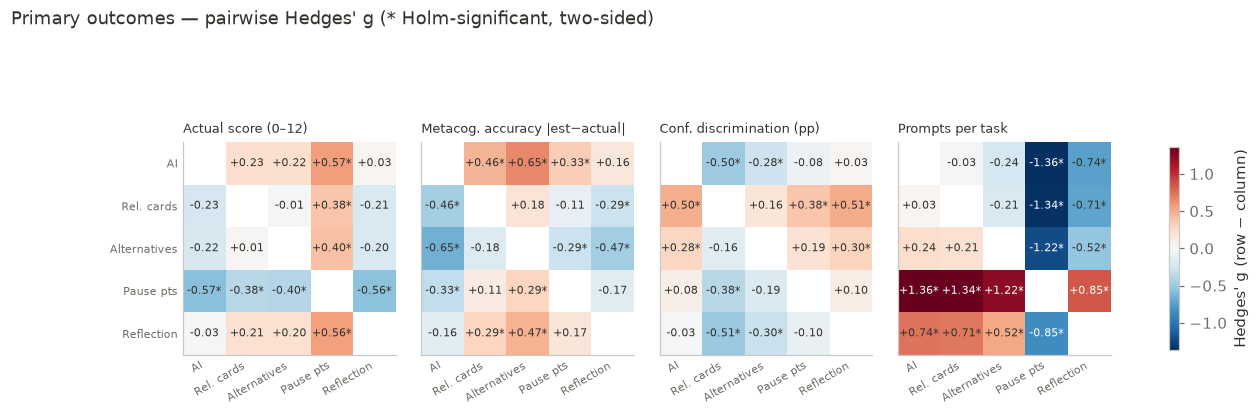

In [5]:
MATRIX_TITLES = {  # compact variants that fit the small-multiple panels
    "absolute_estimation_error": "Metacog. accuracy |est−actual|",
    "confidence_discrimination": "Conf. discrimination (pp)",
    "prompts_per_task": "Prompts per task",
}


def g_matrix(column: str):
    matrix = np.full((5, 5), np.nan)
    significant = np.zeros((5, 5), bool)
    block = pairwise[pairwise["outcome"] == column]
    for _, r in block.iterrows():
        i, j = CONDITIONS.index(r["cond_a"]), CONDITIONS.index(r["cond_b"])
        matrix[i, j], matrix[j, i] = r["hedges_g"], -r["hedges_g"]
        significant[i, j] = significant[j, i] = r["significant"]
    return matrix, significant


def plot_matrices(columns: list[str], title: str):
    fig, axes = plt.subplots(1, len(columns), figsize=(3.4 * len(columns), 3.9))
    fig.subplots_adjust(wspace=0.12, top=0.74)
    limit = max(np.nanmax(np.abs(g_matrix(c)[0])) for c in columns)
    for k, (ax, column) in enumerate(zip(np.atleast_1d(axes), columns)):
        matrix, significant = g_matrix(column)
        image = ax.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit)
        for i in range(5):
            for j in range(5):
                if i == j:
                    continue
                star = "*" if significant[i, j] else ""
                ax.text(j, i, f"{matrix[i, j]:+.2f}{star}", ha="center", va="center",
                        fontsize=7.2,
                        color="white" if abs(matrix[i, j]) > 0.6 * limit else "#33322e")
        ax.set_xticks(range(5), [SHORT_LABELS[c] for c in CONDITIONS], fontsize=7, rotation=30,
                      ha="right")
        if k == 0:
            ax.set_yticks(range(5), [SHORT_LABELS[c] for c in CONDITIONS], fontsize=7)
        else:
            ax.set_yticks(range(5), [""] * 5)
        ax.set_title(MATRIX_TITLES.get(column, OUTCOME_LABELS[column]), fontsize=8.5, loc="left")
        ax.grid(visible=False)
        ax.tick_params(length=0)
    fig.colorbar(image, ax=np.atleast_1d(axes).tolist(), shrink=0.75,
                 label="Hedges' g (row − column)")
    fig.suptitle(title, x=0.01, ha="left", fontsize=12)
    plt.show()


plot_matrices(["actual_score", "absolute_estimation_error",
               "confidence_discrimination", "prompts_per_task"],
              "Primary outcomes — pairwise Hedges' g (* Holm-significant, two-sided)")

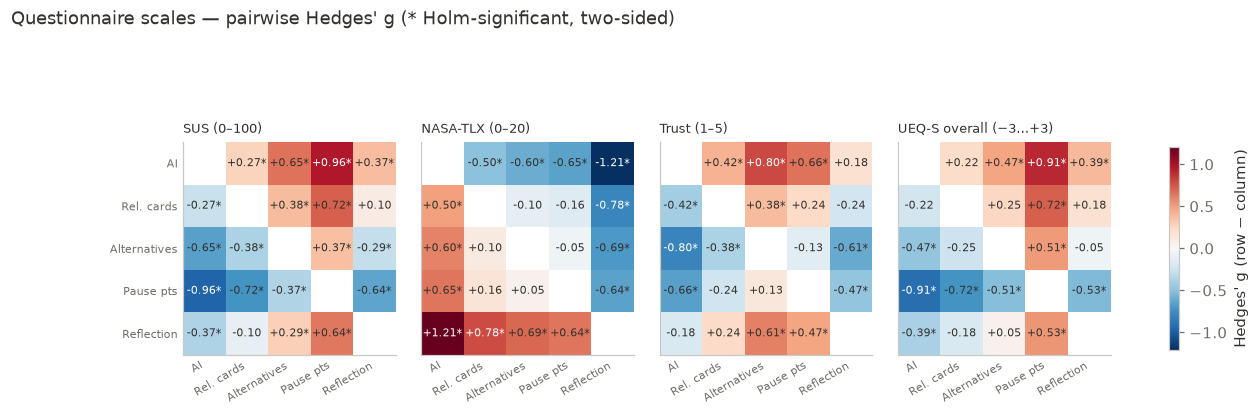

In [6]:
plot_matrices(["sus_score", "tlx_mean", "trust_mean", "ueq_overall"],
              "Questionnaire scales — pairwise Hedges' g (* Holm-significant, two-sided)")

### 6. Every Holm-significant pair

In [7]:
significant = pairwise[pairwise["significant"]].copy()
significant["direction"] = np.where(significant["diff"] > 0, ">", "<")
significant["result"] = (significant["cond_a"].map(SHORT_LABELS) + " "
                         + significant["direction"] + " "
                         + significant["cond_b"].map(SHORT_LABELS))
for family in ("primary", "confidence", "scales", "behavior"):
    print(f"\n[{family}]")
    block = significant[significant["family"] == family]
    if not len(block):
        print("  none")
    for column in dict.fromkeys(block["outcome"]):
        sub = block[block["outcome"] == column]
        parts = [f"{r.result} (g {r.hedges_g:+.2f}{'†' if r.cross_wave else ''})"
                 for r in sub.itertuples()]
        print(f"  {OUTCOME_LABELS[column]}: " + "; ".join(parts))
print("\n† = cross-wave pair (cohort confound possible — see main notebook modules B and O)")


[primary]
  Actual score (0–12): AI > Pause pts (g +0.57†); Rel. cards > Pause pts (g +0.38†); Alternatives > Pause pts (g +0.40); Pause pts < Reflection (g -0.56)
  Metacognitive accuracy |est − actual|: AI > Rel. cards (g +0.46); AI > Alternatives (g +0.65†); AI > Pause pts (g +0.33†); Rel. cards < Reflection (g -0.29†); Alternatives < Pause pts (g -0.29); Alternatives < Reflection (g -0.47)
  Confidence discrimination (pp): AI < Rel. cards (g -0.50); AI < Alternatives (g -0.28†); Rel. cards > Pause pts (g +0.38†); Rel. cards > Reflection (g +0.51†); Alternatives > Reflection (g +0.30)
  Prompts per completed task: AI < Pause pts (g -1.36†); AI < Reflection (g -0.74†); Rel. cards < Pause pts (g -1.34†); Rel. cards < Reflection (g -0.71†); Alternatives < Pause pts (g -1.22); Alternatives < Reflection (g -0.52); Pause pts > Reflection (g +0.85)

[confidence]
  Mean item confidence (0–100): AI > Rel. cards (g +0.61); AI > Alternatives (g +0.57†); AI > Pause pts (g +0.68†); Rel. cards <

### 7. Robustness notes

In [8]:
disagree = pairwise[(pairwise["p_holm"] < ALPHA) != (pairwise["p_mwu_holm"] < ALPHA)]
print(f"Welch vs Mann–Whitney disagreement at Holm-corrected α = .05: "
      f"{len(disagree)} of {len(pairwise)} tests")
if len(disagree):
    view = disagree[["outcome", "pair", "p_holm", "p_mwu_holm", "hedges_g"]].copy()
    view["hedges_g"] = view["hedges_g"].round(2)
    view[["p_holm", "p_mwu_holm"]] = view[["p_holm", "p_mwu_holm"]].map(fmt_p)
    display(view.style.hide(axis="index"))

n_cross = int(pairwise.loc[pairwise['significant'], 'cross_wave'].sum())
n_same = int(pairwise['significant'].sum()) - n_cross
print(f"significant pairs: {n_same} same-wave (confound-free), {n_cross} cross-wave")

Welch vs Mann–Whitney disagreement at Holm-corrected α = .05: 9 of 150 tests


outcome,pair,p_holm,p_mwu_holm,hedges_g
absolute_estimation_error,Rel. cards vs Reflection,= .033,= .075,-0.290000
absolute_estimation_error,Alternatives vs Pause pts,= .033,= .092,-0.290000
prompts_per_task,AI vs Alternatives,= .070,= .018,-0.240000
prompts_per_task,Rel. cards vs Alternatives,= .093,= .044,-0.210000
signed_estimation_error,Alternatives vs Pause pts,= .040,= .077,-0.290000
signed_confidence_gap,AI vs Rel. cards,= .034,= .090,0.310000
signed_confidence_gap,AI vs Alternatives,= .049,= .094,0.290000
trust_mean,Rel. cards vs Reflection,= .080,= .033,-0.240000
double_checked_answers,AI vs Alternatives,= .037,= .082,-0.300000


significant pairs: 36 same-wave (confound-free), 44 cross-wave


### 8. Export

In [9]:
OUTPUT_DIR = Path("notebook_analysis_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
export = pairwise.drop(columns=["family"]).round(
    {c: 4 for c in ("mean_a", "mean_b", "diff", "t", "df", "hedges_g", "g_ci_low", "g_ci_high")})
export.to_csv(OUTPUT_DIR / "pairwise_condition_tests.csv", index=False)
print(f"{OUTPUT_DIR / 'pairwise_condition_tests.csv'}  "
      f"({(OUTPUT_DIR / 'pairwise_condition_tests.csv').stat().st_size / 1e3:.0f} kB, "
      f"{len(export)} rows)")

notebook_analysis_output/pairwise_condition_tests.csv  (33 kB, 150 rows)
